# Equações

**Módulo:** 05 – Trigonometria (7º notebook do módulo)

**Pré-requisitos:** [`0503a_relacoes_fundamentais.ipynb`](0503a_relacoes_fundamentais.ipynb) (diferença entre identidade e equação; relação fundamental, usada nas equações redutíveis ao 2º grau), [`0504a_reducao_ao_1o_quadrante.ipynb`](0504a_reducao_ao_1o_quadrante.ipynb) (necessária para escrever o conjunto solução completo), [`0505a_arcos_notaveis.ipynb`](0505a_arcos_notaveis.ipynb) (muitas soluções recaem em arcos notáveis) e [`0506a_transformacoes.ipynb`](0506a_transformacoes.ipynb) (fórmula de transformação usada nas equações clássicas do tipo a·sen x + b·cos x = c)

**Objetivos de aprendizagem:**
- Resolver as três equações fundamentais (sen x = a, cos x = a, tg x = a) e escrever o conjunto solução geral.
- Restringir o conjunto solução geral a um intervalo específico.
- Resolver equações com múltiplos arcos e equações redutíveis a uma equação do 2º grau.
- Usar as funções circulares inversas e ferramentas computacionais para resolver e conferir equações trigonométricas.

**Tempo estimado:** 100 a 120 minutos (o notebook mais denso do módulo até aqui)

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/05_trigonometria/0507a_equacoes.ipynb)

Lembra da roda-gigante do notebook 2? Descobrimos como calcular a altura da cadeira em qualquer instante de tempo. Mas e se a pergunta for ao contrário: em quais momentos a cadeira estará a exatamente 10 metros de altura? Esse é um problema diferente — agora sabemos o valor da função e precisamos descobrir o(s) valor(es) de x que produzem esse valor. É esse tipo de problema, uma **equação trigonométrica**, que vamos aprender a resolver neste notebook.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)

## 1. Equações Fundamentais

Em [`0503a_relacoes_fundamentais`](0503a_relacoes_fundamentais.ipynb) vimos a diferença entre uma **identidade** (vale para todo x do domínio, como sen²x + cos²x = 1) e uma **equação** (vale só para alguns valores de x). Este notebook é sobre o segundo caso.

As três **equações fundamentais** são:

**sen x = a**    
**cos x = a**    
**tg x = a**

Como seno e cosseno só assumem valores entre −1 e 1, as duas primeiras equações só têm solução se **|a| ≤ 1**. Já a tangente assume qualquer valor real, então tg x = a sempre tem solução, qualquer que seja a.

Por causa da periodicidade das funções circulares, cada uma dessas equações — quando tem solução — costuma ter **infinitas soluções**: se x₀ é solução, x₀ + 2π (ou x₀ + π, no caso da tangente) também é.

In [2]:
# math.asin exige que o argumento esteja entre -1 e 1 -- fora desse
# intervalo, a equação sen x = a não tem solução real
valor_valido = 0.5
valor_invalido = 2.0

print(f"math.asin({valor_valido}) = {math.asin(valor_valido):.4f} rad (existe solução)")

try:
    math.asin(valor_invalido)
except ValueError as erro:
    print(f"math.asin({valor_invalido}) levanta erro: {erro}")
    print("Isso confirma a condição de existência: sen x = 2 não tem solução real.")

math.asin(0.5) = 0.5236 rad (existe solução)
math.asin(2.0) levanta erro: math domain error
Isso confirma a condição de existência: sen x = 2 não tem solução real.


📎 **Conexão:** a diferença entre identidade e equação foi definida em [`0503a_relacoes_fundamentais.ipynb`](0503a_relacoes_fundamentais.ipynb).

**Pergunta de checagem:** por que a equação sen x = 2 não tem solução (em números reais), mas tg x = 1000 tem?

## 2. Resolução de sen α = sen β

No ciclo trigonométrico, dois arcos têm exatamente o mesmo seno em duas situações:

- Se forem **côngruos**: α = β + 2kπ, com k inteiro — o mesmo ponto do ciclo, a menos de voltas completas.
- Se forem **simétricos em relação ao eixo vertical** (o eixo do cosseno): α = π − β + 2kπ, com k inteiro — mesmo seno, cossenos opostos.

Juntando as duas famílias, a **solução geral** de sen α = sen β é:

**α = β + 2kπ  ou  α = π − β + 2kπ,  k ∈ ℤ**

k=-1:  família 1 →  -330.0°   família 2 →  -210.0°
k= 0:  família 1 →    30.0°   família 2 →   150.0°
k= 1:  família 1 →   390.0°   família 2 →   510.0°

Todas essas soluções, e infinitas outras, satisfazem sen x = 1/2.


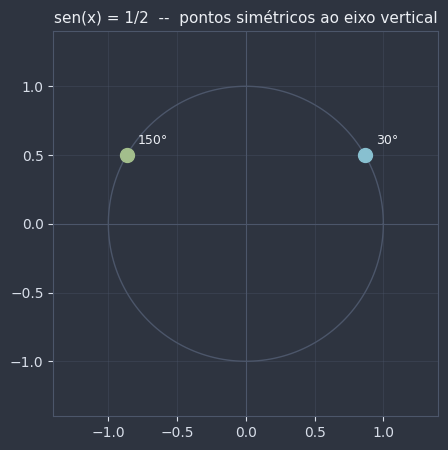

In [3]:
def familia_1_sen(beta: float, k: int) -> float:
    """alpha = beta + 2k*pi (arcos côngruos)."""
    return beta + 2 * k * math.pi


def familia_2_sen(beta: float, k: int) -> float:
    """alpha = pi - beta + 2k*pi (arcos simétricos ao eixo vertical)."""
    return math.pi - beta + 2 * k * math.pi


def plotar_ciclo_com_solucoes(pontos_graus: list[float], titulo: str) -> None:
    """Desenha o ciclo trigonométrico com os pontos (ângulos em graus) destacados."""
    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    angulos_ciclo = np.linspace(0, 2 * np.pi, 200)
    ax.plot(np.cos(angulos_ciclo), np.sin(angulos_ciclo), color=NORD_LINHA, linewidth=1)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)

    cores = [COR_PONTO, COR_DESTAQUE, COR_AVISO, COR_EXTRA]
    for i, angulo_graus in enumerate(pontos_graus):
        angulo_rad = math.radians(angulo_graus)
        x, y = math.cos(angulo_rad), math.sin(angulo_rad)
        ax.plot(x, y, "o", color=cores[i % len(cores)], markersize=10, zorder=5)
        ax.annotate(
            f"{angulo_graus:.0f}°", (x, y),
            textcoords="offset points", xytext=(8, 8),
            color=NORD_TEXTO, fontsize=9,
        )

    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-1.4, 1.4)
    ax.set_aspect("equal")
    ax.set_title(titulo, color=NORD_TEXTO, fontsize=11)
    plt.show()


beta_sen = math.pi / 6  # 30°, sen(30°) = 1/2

for k in range(-1, 2):
    a1 = familia_1_sen(beta_sen, k)
    a2 = familia_2_sen(beta_sen, k)
    assert abs(math.sin(a1) - 0.5) < 1e-9
    assert abs(math.sin(a2) - 0.5) < 1e-9
    print(f"k={k:>2}:  família 1 → {math.degrees(a1):>7.1f}°   família 2 → {math.degrees(a2):>7.1f}°")

print("\nTodas essas soluções, e infinitas outras, satisfazem sen x = 1/2.")

plotar_ciclo_com_solucoes([30, 150], "sen(x) = 1/2  --  pontos simétricos ao eixo vertical")

📌 **Solução geral de sen α = sen β:**

α = β + 2kπ  ou  α = π − β + 2kπ,  com k inteiro

**Pergunta de checagem:** por que a equação sen x = sen(30°) tem duas famílias de soluções, e não apenas uma?

## 3. Resolução de cos α = cos β

O raciocínio é análogo ao do bloco anterior, mas o eixo de simetria muda: dois arcos têm o mesmo cosseno se forem côngruos ou se forem **simétricos em relação ao eixo horizontal** (o eixo do seno) — arcos opostos, um o negativo do outro.

**α = β + 2kπ  ou  α = −β + 2kπ,  k ∈ ℤ**

k=-1:  família 1 →  -225.0°   família 2 →  -495.0°
k= 0:  família 1 →   135.0°   família 2 →  -135.0°
k= 1:  família 1 →   495.0°   família 2 →   225.0°

Todas essas soluções, e infinitas outras, satisfazem cos x = -√2/2.


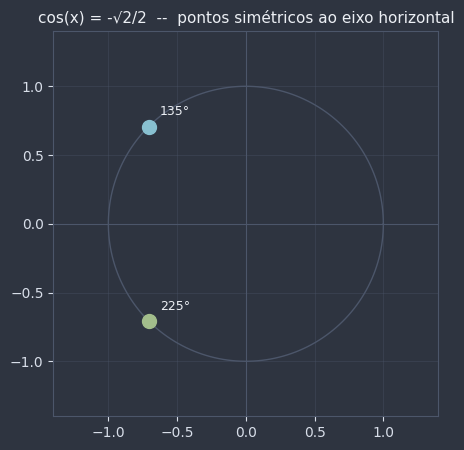

In [4]:
def familia_1_cos(beta: float, k: int) -> float:
    """alpha = beta + 2k*pi (arcos côngruos)."""
    return beta + 2 * k * math.pi


def familia_2_cos(beta: float, k: int) -> float:
    """alpha = -beta + 2k*pi (arcos simétricos ao eixo horizontal)."""
    return -beta + 2 * k * math.pi


beta_cos = 3 * math.pi / 4  # 135°, cos(135°) = -sqrt(2)/2

for k in range(-1, 2):
    a1 = familia_1_cos(beta_cos, k)
    a2 = familia_2_cos(beta_cos, k)
    assert abs(math.cos(a1) - (-math.sqrt(2) / 2)) < 1e-9
    assert abs(math.cos(a2) - (-math.sqrt(2) / 2)) < 1e-9
    print(f"k={k:>2}:  família 1 → {math.degrees(a1):>7.1f}°   família 2 → {math.degrees(a2):>7.1f}°")

print("\nTodas essas soluções, e infinitas outras, satisfazem cos x = -√2/2.")

plotar_ciclo_com_solucoes([135, 225], "cos(x) = -√2/2  --  pontos simétricos ao eixo horizontal")

💡 **Dica:** para não confundir com o caso do seno, lembre-se de qual eixo é o "espelho": vertical para o cosseno... não, o contrário! É o eixo horizontal para o cosseno (e o vertical para o seno). Vale a pena desenhar o ciclo trigonométrico toda vez, até a associação ficar automática.

**Pergunta de checagem:** qual é a diferença entre a segunda família de soluções de sen α = sen β e a de cos α = cos β?

## 4. Resolução de tg α = tg β

A tangente tem período π, e não 2π — então uma única volta de π já repete todos os valores da tangente. Por isso, ao contrário de seno e cosseno, existe **apenas uma família** de soluções:

**α = β + kπ,  k ∈ ℤ**

In [5]:
def familia_tg(beta: float, k: int) -> float:
    """alpha = beta + k*pi (única família, período pi)."""
    return beta + k * math.pi


beta_tg = math.pi / 4  # 45°, tg(45°) = 1

linhas_tabela_tg = []
for k in range(-2, 3):
    a = familia_tg(beta_tg, k)
    assert abs(math.tan(a) - 1) < 1e-9
    linhas_tabela_tg.append({"k": k, "x (graus)": round(math.degrees(a), 1)})

tabela_tg = pd.DataFrame(linhas_tabela_tg)
print("tg(x) = 1  --  uma única família cobre todas as soluções:")
tabela_tg

tg(x) = 1  --  uma única família cobre todas as soluções:


,k,x (graus)
0,-2,-315.0
1,-1,-135.0
2,0,45.0
3,1,225.0
4,2,405.0


⚠️ **Erro comum:** aplicar por hábito as duas famílias de soluções (como em seno e cosseno) também para a tangente. Aqui existe **apenas uma família**, por causa do período menor (π em vez de 2π).

**Pergunta de checagem:** por que a equação da tangente precisa de apenas uma família de soluções, enquanto seno e cosseno precisam de duas?

## 5. Soluções dentro de um Intervalo

As soluções gerais dos blocos anteriores cobrem a reta toda — infinitas soluções, uma para cada valor inteiro de k. Na prática, quase sempre queremos apenas as soluções dentro de um intervalo específico (por exemplo, uma única volta do ciclo, ou um intervalo de tempo). A técnica é sempre a mesma: substituir a solução geral por valores inteiros de k, um de cada vez, e manter apenas os que caem dentro do intervalo desejado.

🎯 **Aplicação prática — voltando à roda-gigante:** em [`0502a_funcoes_circulares.ipynb`](0502a_funcoes_circulares.ipynb) construímos altura_cadeira(t) = 15·sen((π/2)·t − π/2) + 15, com t em minutos e período de 4 minutos por volta. A pergunta do gancho — em que momentos a cadeira está a exatamente 10 metros de altura, dentro de uma única volta — é a equação altura_cadeira(t) = 10, restrita ao intervalo [0, 4).

Isolando o termo com seno: sen((π/2)·t − π/2) = (10 − 15)/15 = −1/3. Esse valor não corresponde a nenhum arco notável, então usamos math.asin para obter uma primeira solução numérica em θ = (π/2)·t − π/2, e as duas famílias do Bloco 2 para obter todas as outras — depois isolamos t em cada uma.

In [6]:
raio_roda = 15  # metros (mesmo valor de 0502a_funcoes_circulares)
periodo_roda = 4  # minutos
velocidade_angular = 2 * math.pi / periodo_roda  # rad/min


def altura_cadeira(t: float) -> float:
    """Altura da cadeira da roda-gigante (em metros) no instante t (em minutos) -- reaproveitada de 0502a_funcoes_circulares."""
    return raio_roda * math.sin(velocidade_angular * t - math.pi / 2) + raio_roda


def resolver_e_restringir(familias: list, intervalo: tuple[float, float], k_max: int = 10) -> list[float]:
    """Gera as soluções de uma lista de famílias (funções de k, em radianos) e devolve as que caem dentro de [início, fim), ordenadas."""
    inicio, fim = intervalo
    solucoes = set()
    for k in range(-k_max, k_max + 1):
        for familia in familias:
            valor = familia(k)
            if inicio <= valor < fim:
                solucoes.add(round(valor, 6))
    return sorted(solucoes)


alvo_altura = 10
seno_alvo = (alvo_altura - raio_roda) / raio_roda
theta0 = math.asin(seno_alvo)  # uma solução em theta = velocidade_angular*t - pi/2

familia_1_t = lambda k: (theta0 + 2 * k * math.pi + math.pi / 2) / velocidade_angular
familia_2_t = lambda k: (math.pi - theta0 + 2 * k * math.pi + math.pi / 2) / velocidade_angular

solucoes_roda_bloco5 = resolver_e_restringir([familia_1_t, familia_2_t], (0, periodo_roda))

print(f"sen(θ) = {seno_alvo:.4f}  (não é um arco notável -- por isso usamos math.asin)")
print(f"instantes em que a cadeira está a {alvo_altura} m, dentro de uma volta: {solucoes_roda_bloco5}")

tabela_roda = pd.DataFrame({
    "t (min)": [round(t, 4) for t in solucoes_roda_bloco5],
    "altura(t) (m)": [round(altura_cadeira(t), 4) for t in solucoes_roda_bloco5],
})
tabela_roda

sen(θ) = -0.3333  (não é um arco notável -- por isso usamos math.asin)
instantes em que a cadeira está a 10 m, dentro de uma volta: [0.783653, 3.216347]


,t (min),altura(t) (m)
0,0.7837,10.0
1,3.2163,10.0


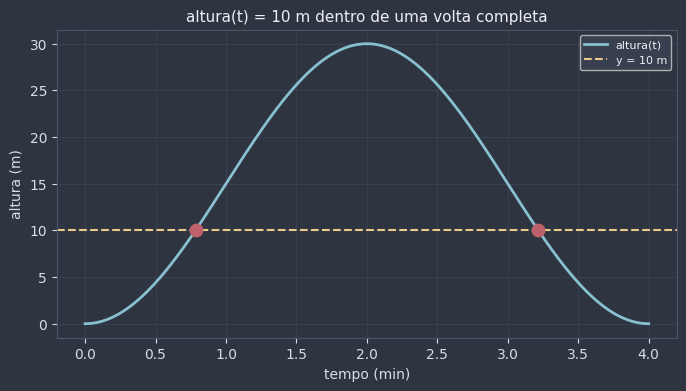

In [7]:
tempos = np.linspace(0, periodo_roda, 400)
alturas = [altura_cadeira(t) for t in tempos]

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(tempos, alturas, color=COR_PONTO, linewidth=2, label="altura(t)")
ax.axhline(alvo_altura, color=COR_AVISO, linewidth=1.5, linestyle="--", label=f"y = {alvo_altura} m")
for t in solucoes_roda_bloco5:
    ax.plot(t, alvo_altura, "o", color=COR_ALERTA, markersize=9, zorder=5)

ax.set_xlabel("tempo (min)", color=NORD_TEXTO_SEC)
ax.set_ylabel("altura (m)", color=NORD_TEXTO_SEC)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8, loc="upper right")
ax.set_title(f"altura(t) = {alvo_altura} m dentro de uma volta completa", color=NORD_TEXTO, fontsize=11)
plt.show()

📎 **Conexão:** a função altura_cadeira foi construída pela primeira vez em [`0502a_funcoes_circulares.ipynb`](0502a_funcoes_circulares.ipynb), Bloco 5.

**Pergunta de checagem:** se a solução geral é x = π/6 + 2kπ, quantas soluções existem no intervalo [0, 4π)?

## 6. Equações com Múltiplos Arcos

Em equações do tipo sen(2x) = a, tratamos 2x como a incógnita da equação fundamental: resolvemos normalmente (obtendo a solução geral em termos de 2x) e só então isolamos x — dividindo **toda** a solução geral por 2, inclusive o termo 2kπ. Como o termo 2kπ também é dividido, o resultado é uma família com "passo" menor (kπ em vez de 2kπ), o que costuma **dobrar** o número de soluções dentro do mesmo intervalo original.

sen(x)  = 1/2  em [0, 2π):  [0.523599, 2.617994]   (2 soluções)
sen(2x) = 1/2  em [0, 2π):  [0.261799, 1.308997, 3.403392, 4.45059]   (4 soluções)


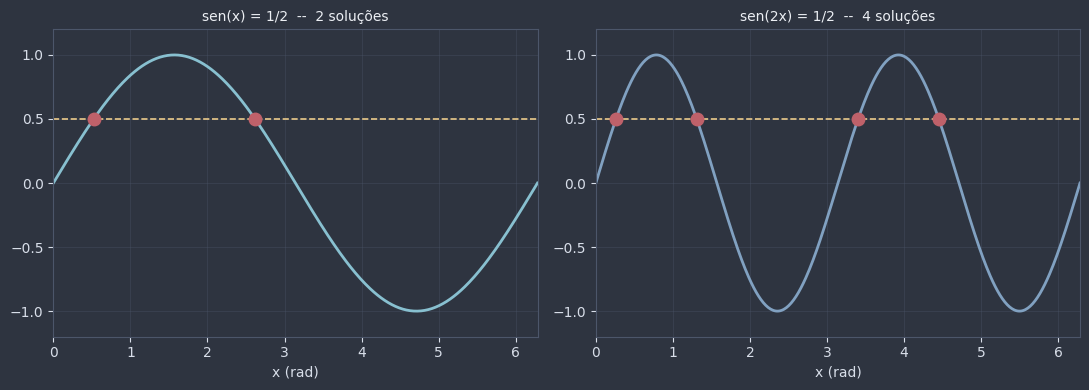

In [8]:
beta_sen2x = math.pi / 6  # sen(2x) = 1/2 -> 2x = beta + 2kpi ou 2x = pi - beta + 2kpi

# resolvendo normalmente para a incógnita 2x, e só depois dividindo TODA a
# expressão por 2 (inclusive o termo 2*k*pi) para isolar x
familia_1_2x = lambda k: familia_1_sen(beta_sen2x, k) / 2
familia_2_2x = lambda k: familia_2_sen(beta_sen2x, k) / 2

solucoes_sen_x = resolver_e_restringir(
    [lambda k: familia_1_sen(beta_sen2x, k), lambda k: familia_2_sen(beta_sen2x, k)],
    (0, 2 * math.pi),
)
solucoes_sen_2x = resolver_e_restringir([familia_1_2x, familia_2_2x], (0, 2 * math.pi))

print(f"sen(x)  = 1/2  em [0, 2π):  {solucoes_sen_x}   ({len(solucoes_sen_x)} soluções)")
print(f"sen(2x) = 1/2  em [0, 2π):  {solucoes_sen_2x}   ({len(solucoes_sen_2x)} soluções)")

xs = np.linspace(0, 2 * np.pi, 400)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
fig.patch.set_facecolor(NORD_FUNDO)
for ax in axs:
    estilizar_eixo(ax)

axs[0].plot(xs, np.sin(xs), color=COR_PONTO, linewidth=2)
axs[0].axhline(0.5, color=COR_AVISO, linewidth=1.2, linestyle="--")
for s in solucoes_sen_x:
    axs[0].plot(s, 0.5, "o", color=COR_ALERTA, markersize=9, zorder=5)
axs[0].set_title(f"sen(x) = 1/2  --  {len(solucoes_sen_x)} soluções", color=NORD_TEXTO, fontsize=10)

axs[1].plot(xs, np.sin(2 * xs), color=COR_SECUNDARIA, linewidth=2)
axs[1].axhline(0.5, color=COR_AVISO, linewidth=1.2, linestyle="--")
for s in solucoes_sen_2x:
    axs[1].plot(s, 0.5, "o", color=COR_ALERTA, markersize=9, zorder=5)
axs[1].set_title(f"sen(2x) = 1/2  --  {len(solucoes_sen_2x)} soluções", color=NORD_TEXTO, fontsize=10)

for ax in axs:
    ax.set_xlim(0, 2 * np.pi)
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel("x (rad)", color=NORD_TEXTO_SEC)

plt.tight_layout()
plt.show()

⚠️ **Erro comum:** esquecer de dividir toda a expressão da solução geral por 2 (inclusive o termo 2kπ) ao isolar x, o que faz perder metade das soluções dentro do intervalo.

**Pergunta de checagem:** por que sen(2x) = 1/2 tem mais soluções no intervalo [0, 2π) do que sen(x) = 1/2?

## 7. Equações Redutíveis ao 2º Grau

Algumas equações, usando a relação fundamental sen²x + cos²x = 1, podem ser reescritas como uma equação do 2º grau em u = sen x (ou u = cos x). O sinal característico é a presença de sen²x (ou cos²x) e sen x (ou cos x) na mesma expressão.

Exemplo clássico: 2·sen²x − sen x − 1 = 0 vira 2u² − u − 1 = 0 (com u = sen x). Resolvendo com a fórmula de Bhaskara, obtemos as raízes em u — e só então resolvemos sen x = u para cada raiz, **descartando as que estiverem fora do intervalo [−1, 1]** (nenhum valor de x produz um seno fora desse intervalo).

In [9]:
def bhaskara(a: float, b: float, c: float) -> tuple[float, float]:
    """Resolve a*x^2 + b*x + c = 0 pela fórmula de Bhaskara (assume delta >= 0)."""
    delta = b ** 2 - 4 * a * c
    raiz_delta = math.sqrt(delta)
    x1 = (-b + raiz_delta) / (2 * a)
    x2 = (-b - raiz_delta) / (2 * a)
    return x1, x2


# 2*sen^2(x) - sen(x) - 1 = 0  vira  2u^2 - u - 1 = 0, com u = sen(x)
u1, u2 = bhaskara(2, -1, -1)
print(f"raízes da equação do 2º grau: u1 = {u1}, u2 = {u2}")

for u in (u1, u2):
    if abs(u) <= 1:
        print(f"  u = {u}: válida (está em [-1, 1]) -> resolver sen(x) = {u}")
    else:
        print(f"  u = {u}: descartada (fora de [-1, 1])")

# u1 = 1 -> sen(x) = 1, uma única família (x = pi/2 + 2kpi)
x_de_u1 = math.pi / 2
assert abs(math.sin(x_de_u1) - u1) < 1e-9

# u2 = -1/2 -> sen(x) = -1/2, beta = -pi/6 (sen(-30°) = -1/2)
beta_de_u2 = -math.pi / 6
assert abs(math.sin(beta_de_u2) - u2) < 1e-9

print(f"\nsolução base de sen(x) = {u1}:  x = {math.degrees(x_de_u1):.1f}° (+ 2kπ)")
print(f"solução base de sen(x) = {u2}:  x = {math.degrees(beta_de_u2):.1f}° ou "
      f"{math.degrees(math.pi - beta_de_u2):.1f}° (+ 2kπ)")

raízes da equação do 2º grau: u1 = 1.0, u2 = -0.5
  u = 1.0: válida (está em [-1, 1]) -> resolver sen(x) = 1.0
  u = -0.5: válida (está em [-1, 1]) -> resolver sen(x) = -0.5

solução base de sen(x) = 1.0:  x = 90.0° (+ 2kπ)
solução base de sen(x) = -0.5:  x = -30.0° ou 210.0° (+ 2kπ)


💡 **Dica:** o sinal de que uma equação é "disfarçada" de 2º grau costuma ser a presença de sen²x (ou cos²x) e sen x (ou cos x) na mesma expressão, sem outras funções misturadas.

**Pergunta de checagem:** depois de resolver a equação do 2º grau em u, por que é preciso conferir se cada raiz está entre −1 e 1 antes de continuar?

📖 **Leitura complementar:** [Equação quadrática — Wikipédia](https://pt.wikipedia.org/wiki/Equa%C3%A7%C3%A3o_quadr%C3%A1tica)

## 8. Equações Clássicas (a·sen x + b·cos x = c)

Equações que misturam seno e cosseno do mesmo arco, como a·sen x + b·cos x = c, podem ser resolvidas pelo **método do ângulo auxiliar**: reescrever a·sen x + b·cos x como R·sen(x + φ), onde

**R = √(a² + b²)**,  com  **cos φ = a/R**  e  **sen φ = b/R**

usando diretamente a fórmula de adição vista em [`0506a_transformacoes.ipynb`](0506a_transformacoes.ipynb) (R·sen(x + φ) = R·sen x·cos φ + R·cos x·sen φ = a·sen x + b·cos x, substituindo R·cos φ = a e R·sen φ = b). A equação original vira R·sen(x + φ) = c, que já sabemos resolver.

In [10]:
def resolver_angulo_auxiliar(a: float, b: float, c: float) -> tuple[float, float]:
    """Reescreve a*sen(x) + b*cos(x) = c como R*sen(x + phi) = c e devolve (R, phi)."""
    R = math.sqrt(a ** 2 + b ** 2)
    phi = math.atan2(b, a)  # cos(phi) = a/R, sen(phi) = b/R
    return R, phi


a_coef, b_coef, c_coef = 1, 1, 1  # sen x + cos x = 1
R, phi = resolver_angulo_auxiliar(a_coef, b_coef, c_coef)
print(f"R = {R:.4f}, φ = {math.degrees(phi):.1f}°")

# a equação vira R*sen(x + phi) = c, ou seja, sen(x + phi) = c/R
seno_alvo_8 = c_coef / R
beta_8 = math.asin(seno_alvo_8)
print(f"sen(x + φ) = {seno_alvo_8:.4f}  ->  x + φ = {math.degrees(beta_8):.1f}° ou "
      f"{math.degrees(math.pi - beta_8):.1f}°  (+ 2kπ)")

x1 = beta_8 - phi
x2 = (math.pi - beta_8) - phi

print(f"\nx1 = {math.degrees(x1):.1f}°   x2 = {math.degrees(x2):.1f}°")
assert abs(a_coef * math.sin(x1) + b_coef * math.cos(x1) - c_coef) < 1e-9
assert abs(a_coef * math.sin(x2) + b_coef * math.cos(x2) - c_coef) < 1e-9
print("As duas soluções conferem: a*sen(x) + b*cos(x) = c.")

R = 1.4142, φ = 45.0°
sen(x + φ) = 0.7071  ->  x + φ = 45.0° ou 135.0°  (+ 2kπ)

x1 = -0.0°   x2 = 90.0°
As duas soluções conferem: a*sen(x) + b*cos(x) = c.


🕵️ **Curiosidade histórica:** essa é exatamente a mesma ideia por trás de representar uma onda como amplitude e fase (vista em [`0502a_funcoes_circulares.ipynb`](0502a_funcoes_circulares.ipynb), Bloco 5); a matemática por trás de "somar seno e cosseno" é a mesma nos dois contextos.

**Pergunta de checagem:** no método do ângulo auxiliar, o que representa fisicamente o valor de R = √(a² + b²)?

## 9. Funções Circulares Inversas

Arco seno, arco cosseno e arco tangente são as funções inversas de seno, cosseno e tangente — mas para que uma função tenha inversa, ela precisa ser injetora, e nenhuma função periódica é injetora em todo o seu domínio. A solução é **restringir o domínio**: o seno, restrito a [−π/2, π/2], é injetor (e ainda cobre toda a imagem [−1, 1]) — é nesse domínio restrito que se define arcsen. Cosseno e tangente seguem a mesma ideia, com domínios restritos diferentes.

A diferença essencial em relação ao resto do notebook: **arcsen(a) devolve um único valor**, enquanto a equação sen x = a tem infinitas soluções. A função inversa dá apenas o representante "oficial" de cada família — a partir dele, as fórmulas dos Blocos 2 a 4 reconstroem todas as outras soluções.

In [11]:
valor_a = 0.5
solucao_arcsin = math.asin(valor_a)
print(f"math.asin({valor_a}) = {solucao_arcsin:.4f} rad = {math.degrees(solucao_arcsin):.1f}°  (um único valor)")

solucoes_gerais = resolver_e_restringir(
    [lambda k: familia_1_sen(solucao_arcsin, k), lambda k: familia_2_sen(solucao_arcsin, k)],
    (-4 * math.pi, 4 * math.pi),
)
print(f"solução geral de sen(x) = {valor_a}, em [-4π, 4π):  "
      f"{[round(math.degrees(s), 1) for s in solucoes_gerais]}°  ({len(solucoes_gerais)} valores)")

tabela_arcsin = pd.DataFrame({
    "k": list(range(-2, 3)),
    "família 1 (graus)": [round(math.degrees(familia_1_sen(solucao_arcsin, k)), 1) for k in range(-2, 3)],
    "família 2 (graus)": [round(math.degrees(familia_2_sen(solucao_arcsin, k)), 1) for k in range(-2, 3)],
})
tabela_arcsin

math.asin(0.5) = 0.5236 rad = 30.0°  (um único valor)
solução geral de sen(x) = 0.5, em [-4π, 4π):  [-690.0, -570.0, -330.0, -210.0, 30.0, 150.0, 390.0, 510.0]°  (8 valores)


,k,família 1 (graus),família 2 (graus)
0,-2,-690.0,-570.0
1,-1,-330.0,-210.0
2,0,30.0,150.0
3,1,390.0,510.0
4,2,750.0,870.0


📌 **Definição formal — funções circulares inversas** (domínio restrito para que a função original seja invertível):

| Função | Domínio | Imagem |
|---|---|---|
| arcsen(x) | [−1, 1] | [−π/2, π/2] |
| arccos(x) | [−1, 1] | [0, π] |
| arctg(x) | ℝ | (−π/2, π/2) |

**Pergunta de checagem:** por que é preciso restringir o domínio do seno para definir sua função inversa?

📖 **Leitura complementar:** [Arcotangente — Wikipédia](https://pt.wikipedia.org/wiki/Arcotangente)

## 10. Resolução Numérica e Gráfica com Python

Duas formas computacionais de resolver (e conferir) equações trigonométricas, além do cálculo manual dos blocos anteriores:

- **Simbolicamente**, com `sympy.solveset(equação, x, domain=...)` — o `domain` pode ser um intervalo (`sp.Interval`) para já restringir a solução, ou `sp.S.Reals` para obter a solução geral completa (como um conjunto de fórmulas parametrizadas por um inteiro).
- **Graficamente**, plotando os dois lados da equação como funções separadas e marcando os pontos onde os gráficos se cruzam — a interseção é, por definição, onde as duas expressões são iguais.

🎯 **Aplicação prática (síntese final) — a roda-gigante, resolvida de novo:** o Bloco 5 resolveu altura_cadeira(t) = 10 manualmente, combinando math.asin com as famílias de solução. Agora resolvemos a mesma equação com sympy (restringindo o domínio diretamente ao intervalo de uma volta) e conferimos o resultado com o método gráfico — plotando altura_cadeira(t) e a reta y = 10, e marcando as interseções.

solução simbólica (sympy): {2*(-acos(1/3) + 2*pi)/pi, 2*acos(1/3)/pi}
valores numéricos (minutos): [0.7837, 3.2163]
solução manual do Bloco 5:   [0.783653, 3.216347]

Os dois métodos concordam.


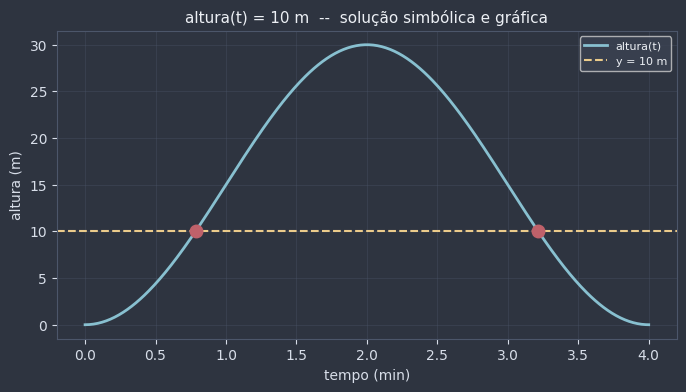

In [12]:
t_sym = sp.symbols("t", real=True)
velocidade_sym = 2 * sp.pi / periodo_roda  # forma exata, equivalente a velocidade_angular

equacao_roda = raio_roda * sp.sin(velocidade_sym * t_sym - sp.pi / 2) + raio_roda - alvo_altura

solucao_simbolica_roda = sp.solveset(equacao_roda, t_sym, domain=sp.Interval(0, periodo_roda, False, True))
solucoes_numericas_roda = sorted(float(s) for s in solucao_simbolica_roda)

print(f"solução simbólica (sympy): {solucao_simbolica_roda}")
print(f"valores numéricos (minutos): {[round(s, 4) for s in solucoes_numericas_roda]}")
print(f"solução manual do Bloco 5:   {solucoes_roda_bloco5}")

assert all(abs(a - b) < 1e-4 for a, b in zip(solucoes_numericas_roda, solucoes_roda_bloco5))
print("\nOs dois métodos concordam.")

tempos = np.linspace(0, periodo_roda, 400)
alturas = [altura_cadeira(t) for t in tempos]

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(tempos, alturas, color=COR_PONTO, linewidth=2, label="altura(t)")
ax.axhline(alvo_altura, color=COR_AVISO, linewidth=1.5, linestyle="--", label=f"y = {alvo_altura} m")
for t in solucoes_numericas_roda:
    ax.plot(t, alvo_altura, "o", color=COR_ALERTA, markersize=9, zorder=5)

ax.set_xlabel("tempo (min)", color=NORD_TEXTO_SEC)
ax.set_ylabel("altura (m)", color=NORD_TEXTO_SEC)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8, loc="upper right")
ax.set_title("altura(t) = 10 m  --  solução simbólica e gráfica", color=NORD_TEXTO, fontsize=11)
plt.show()

🕹️ **Widget interativo:** digite o valor de a em sen(x) = a e veja, lado a lado, a solução simbólica do `sympy` (restrita a uma volta, [0, 2π)) e o gráfico com os pontos de interseção destacados.

In [13]:
def resolver_e_plotar_sen(a: float) -> None:
    """Resolve sen(x) = a simbolicamente (sympy) e plota o gráfico com os pontos de interseção, no intervalo [0, 2π)."""
    x_sym = sp.symbols("x", real=True)
    solucao = sp.solveset(sp.sin(x_sym) - a, x_sym, domain=sp.Interval(0, 2 * sp.pi, False, True))
    solucoes_numericas = sorted(float(s) for s in solucao)

    print(f"sen(x) = {a}")
    print(f"solução simbólica (sympy): {solucao}")
    print(f"valores numéricos em [0, 2π): {[round(s, 4) for s in solucoes_numericas]}")

    xs = np.linspace(0, 2 * np.pi, 400)
    ys = np.sin(xs)

    fig, ax = plt.subplots(figsize=(8, 4))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs, ys, color=COR_PONTO, linewidth=2, label="sen(x)")
    ax.axhline(a, color=COR_AVISO, linewidth=1.5, linestyle="--", label=f"y = {a}")
    for s in solucoes_numericas:
        ax.plot(s, a, "o", color=COR_ALERTA, markersize=9, zorder=5)

    ax.set_xlim(0, 2 * np.pi)
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel("x (rad)", color=NORD_TEXTO_SEC)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8, loc="upper right")
    ax.set_title(f"sen(x) = {a}  --  {len(solucoes_numericas)} solução(ões) em [0, 2π)", color=NORD_TEXTO, fontsize=11)
    plt.show()


widgets.interact(
    resolver_e_plotar_sen,
    a=widgets.FloatSlider(min=-0.99, max=0.99, step=0.01, value=0.5, description="a"),
)

interactive(children=(FloatSlider(value=0.5, description='a', max=0.99, min=-0.99, step=0.01), Output()), _dom…

<function __main__.resolver_e_plotar_sen(a: float) -> None>

📎 **Conexão:** este problema foi resolvido de forma manual no Bloco 5; aqui usamos ferramentas computacionais para conferir (e generalizar) o resultado.

**Pergunta de checagem:** em que situações o método gráfico é mais útil que a solução simbólica exata, e vice-versa?

## Resumo — cheat sheet

**Equações fundamentais e condições de existência:**

| Equação | Existe solução se... |
|---|---|
| sen x = a | \|a\| ≤ 1 |
| cos x = a | \|a\| ≤ 1 |
| tg x = a | qualquer a real |

**Soluções gerais** (k inteiro em todos os casos):

| Equação | Solução geral |
|---|---|
| sen α = sen β | α = β + 2kπ ou α = π − β + 2kπ |
| cos α = cos β | α = β + 2kπ ou α = −β + 2kπ |
| tg α = tg β | α = β + kπ |

**Restringindo a um intervalo:** substitua a solução geral (com k inteiro) e teste os valores de k que caem dentro do intervalo desejado.

**Múltiplos arcos** (ex.: sen(2x) = a): resolva normalmente tratando 2x como a incógnita, depois divida TODA a expressão da solução geral por 2 — inclusive o termo 2kπ. Esquecer disso faz perder metade das soluções.

**Equações redutíveis ao 2º grau:** reescreva usando a relação fundamental como uma equação do 2º grau em u = sen x (ou u = cos x), resolva com Bhaskara e descarte raízes fora de [−1, 1].

**Método do ângulo auxiliar** (a·sen x + b·cos x = c): reescreva como R·sen(x + φ) = c, com R = √(a² + b²), cos φ = a/R e sen φ = b/R.

**Funções circulares inversas** (domínio restrito para serem invertíveis):

| Função | Domínio | Imagem |
|---|---|---|
| arcsen | [−1, 1] | [−π/2, π/2] |
| arccos | [−1, 1] | [0, π] |
| arctg | ℝ | (−π/2, π/2) |

**Ferramentas computacionais:** `sympy.solveset(equação, x, domain=...)` resolve simbolicamente; plotar os dois lados da equação e marcar as interseções resolve graficamente.

## Exercícios

**Básico**
1. Resolver sen(x) = √3/2, escrevendo os dois primeiros valores de cada família de solução (em graus) no intervalo [0°, 360°).
2. Restringir a solução geral de cos(x) = −1/2 ao intervalo [0, 4π) (duas voltas completas).

**Intermediário**
3. Resolver cos(3x) = √2/2 no intervalo [0, 2π), tratando 3x como a incógnita.
4. Resolver a equação redutível ao 2º grau 2·cos²x + cos x − 1 = 0, conferindo se as raízes são válidas.

**Desafio**
5. Resolver √3·sen x + cos x = 1 usando o método do ângulo auxiliar, do início ao fim.
6. Problema aplicado: a partir de um modelo de temperatura ao longo do dia, descobrir os horários em que ela atinge um valor específico, conferindo com `sympy`.

### Básico

In [ ]:
# Exercício Básico 1: resolva sen(x) = √3/2 (beta = pi/3, já que sen(60°) =
# √3/2) usando as funções familia_1_sen e familia_2_sen (definidas na seção
# 2). Encontre o primeiro valor (k=0) de cada família, em graus,
# arredondados a 1 casa decimal. Guarde o resultado como uma tupla
# (x_familia1, x_familia2).
resultado_ex1 = ...

In [ ]:
# Verificação
beta_ex1 = math.pi / 3
esperado_ex1 = (
    round(math.degrees(familia_1_sen(beta_ex1, 0)), 1),
    round(math.degrees(familia_2_sen(beta_ex1, 0)), 1),
)
assert resultado_ex1 == esperado_ex1, (
    "Tente de novo, revise: use familia_1_sen(beta, 0) e familia_2_sen(beta, 0), "
    "com beta = pi/3 (60°, já que sen(60°) = √3/2), e converta para graus com "
    "math.degrees (seção 2 - Resolução de sen α = sen β)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: resolva cos(x) = -1/2 (beta = 2*pi/3, já que
# cos(120°) = -1/2) no intervalo [0, 4*pi) (duas voltas completas), usando
# familia_1_cos, familia_2_cos (seção 3) e resolver_e_restringir (seção 5).
# Guarde o resultado (lista ordenada de floats em radianos, arredondados a 4
# casas decimais) em solucoes_ex2.
beta_ex2 = 2 * math.pi / 3
solucoes_ex2 = ...

In [ ]:
# Verificação
esperado_ex2 = resolver_e_restringir(
    [lambda k: familia_1_cos(beta_ex2, k), lambda k: familia_2_cos(beta_ex2, k)],
    (0, 4 * math.pi),
)
assert solucoes_ex2 == esperado_ex2, (
    "Tente de novo, revise: use resolver_e_restringir com familia_1_cos e "
    "familia_2_cos, beta = 2*pi/3, e intervalo (0, 4*pi) "
    "(seção 5 - Soluções dentro de um Intervalo)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: resolva cos(3x) = √2/2 (beta = pi/4) no
# intervalo [0, 2*pi), tratando 3x como a incógnita: resolva normalmente
# (familia_1_cos, familia_2_cos) e depois divida TODA a solução geral por 3
# (inclusive o termo 2*k*pi -- seção 6). Use resolver_e_restringir. Guarde o
# resultado (lista ordenada de floats em radianos, arredondados a 4 casas
# decimais) em solucoes_ex3.
beta_ex3 = math.pi / 4
solucoes_ex3 = ...

In [ ]:
# Verificação
esperado_ex3 = resolver_e_restringir(
    [
        lambda k: familia_1_cos(beta_ex3, k) / 3,
        lambda k: familia_2_cos(beta_ex3, k) / 3,
    ],
    (0, 2 * math.pi),
)
assert solucoes_ex3 == esperado_ex3, (
    "Tente de novo, revise: resolva para u = 3x normalmente e só depois "
    "divida toda a solução geral por 3, inclusive o termo 2*k*pi "
    "(seção 6 - Equações com Múltiplos Arcos)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: a equação 2*cos²x + cos x - 1 = 0 vira
# 2*u² + u - 1 = 0, com u = cos x. Resolva com a função bhaskara (seção 7) e
# guarde as duas raízes como uma tupla ordenada (do menor para o maior),
# arredondadas a 4 casas decimais, em raizes_ex4. Depois, guarde em
# raizes_validas_ex4 (lista) apenas as raízes que estão em [-1, 1].
raizes_ex4 = ...
raizes_validas_ex4 = ...

In [ ]:
# Verificação
u1_ex4, u2_ex4 = bhaskara(2, 1, -1)
esperado_raizes_ex4 = tuple(sorted([round(u1_ex4, 4), round(u2_ex4, 4)]))
esperado_validas_ex4 = [u for u in esperado_raizes_ex4 if abs(u) <= 1]
assert raizes_ex4 == esperado_raizes_ex4, (
    "Tente de novo, revise: use bhaskara(2, 1, -1) para obter as raízes de "
    "2u² + u - 1 = 0 (seção 7 - Equações Redutíveis ao 2º Grau)."
)
assert raizes_validas_ex4 == esperado_validas_ex4, (
    "Tente de novo, revise: uma raiz de cos x = u só é válida se "
    "-1 ≤ u ≤ 1 (seção 7 - Equações Redutíveis ao 2º Grau)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: resolva √3*sen x + cos x = 1 usando o método do
# ângulo auxiliar (seção 8): calcule R = sqrt(a² + b²) e phi (com cos(phi) =
# a/R e sen(phi) = b/R), reescreva como R*sen(x + phi) = c, resolva para
# x + phi e isole x. Guarde as duas primeiras soluções não negativas (a
# partir de x = 0) como uma tupla ordenada (x1, x2), em radianos,
# arredondadas a 4 casas decimais, em solucao_ex5.
a_ex5, b_ex5, c_ex5 = math.sqrt(3), 1, 1
solucao_ex5 = ...

In [ ]:
# Verificação
R_ex5 = math.sqrt(a_ex5 ** 2 + b_ex5 ** 2)
phi_ex5 = math.atan2(b_ex5, a_ex5)
beta_ex5 = math.asin(c_ex5 / R_ex5)
candidatos_ex5 = sorted(
    v for k in range(-2, 3)
    for v in (
        beta_ex5 - phi_ex5 + 2 * k * math.pi,
        math.pi - beta_ex5 - phi_ex5 + 2 * k * math.pi,
    )
    if v >= -1e-9
)
esperado_ex5 = tuple(round(v, 4) for v in candidatos_ex5[:2])
assert solucao_ex5 == esperado_ex5, (
    "Tente de novo, revise: R = sqrt(3 + 1) = 2, cos(phi) = √3/2 e "
    "sen(phi) = 1/2 (phi = 30°); resolva sen(x + phi) = 1/2 e isole x "
    "(seção 8 - Equações Clássicas)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6: a temperatura T (em °C) de uma cidade ao longo do dia
# é modelada por T(h) = 6*sen(pi/12*(h - 9)) + 20, com h em horas
# (0 <= h < 24). Usando sympy.solveset restrito ao intervalo [0, 24) (como
# na seção 10), encontre os horários em que T(h) = 23. Guarde o resultado
# como uma tupla ordenada de floats (horas, arredondadas a 2 casas
# decimais) em horarios_ex6.
h_sym = sp.symbols("h", real=True)
horarios_ex6 = ...

In [ ]:
# Verificação
equacao_ex6 = 6 * sp.sin(sp.pi / 12 * (h_sym - 9)) + 20 - 23
solucao_ex6 = sp.solveset(equacao_ex6, h_sym, domain=sp.Interval(0, 24, False, True))
esperado_ex6 = tuple(sorted(round(float(s), 2) for s in solucao_ex6))
assert horarios_ex6 == esperado_ex6, (
    "Tente de novo, revise: monte a equação 6*sen(pi/12*(h-9)) + 20 - 23 e "
    "resolva com sp.solveset(..., domain=sp.Interval(0, 24, False, True)) "
    "(seção 10 - Resolução Numérica e Gráfica com Python)."
)
print("Certo!")

## Glossário do bloco

| Termo | Definição |
|---|---|
| Equação trigonométrica | igualdade envolvendo funções circulares que vale só para alguns valores de x, ao contrário de uma identidade |
| Condição de existência | restrição sobre a (como \|a\| ≤ 1) para que a equação tenha solução real |
| Família de soluções | conjunto de soluções gerado por uma fórmula parametrizada por um inteiro k |
| Múltiplo arco | equação em que a incógnita aparece multiplicada (como em sen(2x) = a); exige dividir toda a solução geral pelo mesmo fator |
| Equação redutível ao 2º grau | equação trigonométrica que, via substituição u = sen x (ou cos x), vira uma equação polinomial do 2º grau |
| Método do ângulo auxiliar | técnica que reescreve a·sen x + b·cos x como R·sen(x + φ), usando a fórmula de adição de arcos |
| Funções circulares inversas | arcsen, arccos, arctg — inversas de seno, cosseno e tangente, definidas em domínios restritos |
| Resolução simbólica | uso de `sympy.solveset` para obter a solução exata (geral ou restrita a um domínio) |
| Resolução gráfica | plotar os dois lados da equação e marcar os pontos de interseção como solução |

## Conexões

**Isso depende de:**
- [`0503a_relacoes_fundamentais.ipynb`](0503a_relacoes_fundamentais.ipynb) (diferença entre identidade e equação; relação fundamental, usada nas equações redutíveis ao 2º grau)
- [`0504a_reducao_ao_1o_quadrante.ipynb`](0504a_reducao_ao_1o_quadrante.ipynb) (necessária para escrever o conjunto solução completo)
- [`0505a_arcos_notaveis.ipynb`](0505a_arcos_notaveis.ipynb) (muitas soluções recaem em arcos notáveis)
- [`0506a_transformacoes.ipynb`](0506a_transformacoes.ipynb) (fórmula de transformação usada nas equações clássicas do tipo a·sen x + b·cos x = c)

**Isso será usado em:**
- 📌 Inequações (resolver uma inequação trigonométrica exige primeiro saber resolver a equação correspondente)
- 📌 Triângulos Retângulos e 📌 Triângulos Quaisquer (funções circulares inversas são usadas para encontrar ângulos a partir de razões conhecidas)
- [`11_limite_integral_e_derivada/`](../11_limite_integral_e_derivada/) (as funções circulares inversas reaparecem como funções a derivar e integrar)